In [26]:
%pip install mlxtend ucimlrepo -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


# Proyecto Semestral: Prediccion de Niveles de Obesidad
**Curso:** Ingenieria de Datos 2026  
**Dataset:** Estimation of Obesity Levels Based On Eating Habits and Physical Condition

## 1. Definicion del Problema y Dataset

- **Nombre del Dataset:** Estimation of Obesity Levels Based On Eating Habits and Physical Condition
- **Fuente:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)
- **Descripcion General:** Datos de individuos de Mexico, Peru y Colombia para estimar niveles de obesidad basados en habitos alimenticios y condicion fisica.
- **Numero de Registros:** 2111
- **Numero de Variables:** 17 (16 caracteristicas + 1 objetivo)
- **Variable Objetivo:** `NObeyesdad` (7 niveles de peso)
- **Licencia:** Creative Commons Attribution 4.0 International (CC BY 4.0).

**Problema de Machine Learning:**
- **Tipo de Tarea:** Clasificacion Multiclase.
- **Pregunta de Investigacion:** Es posible predecir con precision el nivel de obesidad de un individuo a partir de sus habitos diarios de alimentacion y actividad fisica, sin usar peso ni altura?
- **Contexto de Uso:** Herramientas de salud preventiva y aplicaciones de bienestar.
- **Criterio de Exito:** Alcanzar un Accuracy y F1-Score (macro) superior al 85% en el conjunto de prueba.

### Diccionario de Variables

| Variable | Tipo | Descripcion |
| :--- | :--- | :--- |
| **Gender** | Categorica | Genero del individuo (Male / Female) |
| **Age** | Numerica | Edad del individuo |
| **Height** | Numerica | Altura en metros |
| **Weight** | Numerica | Peso en kilogramos |
| **family_history_with_overweight** | Categorica | Historial familiar de sobrepeso (Yes / No) |
| **FAVC** | Categorica | Consumo frecuente de alimentos hipercaloricos (Yes / No) |
| **FCVC** | Numerica | Frecuencia de consumo de verduras (1, 2 o 3) |
| **NCP** | Numerica | Numero de comidas principales al dia |
| **CAEC** | Categorica | Consumo de alimentos entre comidas |
| **SMOKE** | Categorica | Si el individuo fuma (Yes / No) |
| **CH2O** | Numerica | Consumo diario de agua en litros |
| **SCC** | Categorica | Monitoreo del consumo de calorias (Yes / No) |
| **FAF** | Numerica | Frecuencia de actividad fisica semanal |
| **TUE** | Numerica | Tiempo de uso de dispositivos tecnologicos |
| **CALC** | Categorica | Consumo de alcohol |
| **MTRANS** | Categorica | Medio de transporte utilizado |
| **NObeyesdad** | Categorica | **Variable Objetivo:** Nivel de peso (7 clases) |

## Justificacion

La obesidad es una de las crisis de salud publica mas complejas a nivel global. Este dataset permite modelar la relacion entre habitos diarios y niveles de masa corporal usando Machine Learning como herramienta de diagnostico temprano. Se excluyen Weight y Height del entrenamiento para evitar data leakage, forzando al modelo a aprender patrones reales de habitos y estilo de vida.

In [27]:
# Cargar dataset desde UCI
obesity_data = fetch_ucirepo(id=544)
X = obesity_data.data.features
y = obesity_data.data.targets

print(obesity_data.metadata)
print(obesity_data.variables)

{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

### Interpretación de la Carga de Datos

El dataset se descargó exitosamente del repositorio UCI Machine Learning. Contiene **2111 registros** con **17 variables** (16 features + 1 target).
No se reportan valores nulos en ninguna variable, lo cual simplifica el preprocesamiento. Las variables incluyen datos demográficos (Gender, Age), medidas físicas (Height, Weight), hábitos alimenticios (FAVC, FCVC, CAEC, CALC), actividad física (FAF), uso de tecnología (TUE), y la variable objetivo NObeyesdad con 7 niveles de peso.

In [28]:
dataset = pd.concat([X, y], axis=1)
print(f"Dataset creado. Dimensiones: {dataset.shape}")

Dataset creado. Dimensiones: (2111, 17)


---
## 2. Analisis Exploratorio de Datos (EDA)

### Observaciones del EDA — Valores Nulos y Duplicados

Confirmamos que **no hay valores nulos** en ninguna columna, lo que nos ahorra pasos de imputación. Sin embargo, detectamos **24 registros duplicados**. Aunque son pocos (apenas el 1.1% del dataset), eliminarlos es una buena práctica para evitar que el modelo aprenda de observaciones repetidas, lo que podría inflar artificialmente las métricas de rendimiento.

También normalizamos las columnas `CAEC` y `CALC` para uniformizar mayúsculas/minúsculas (por ejemplo, `'Sometimes'` en lugar de `'sometimes'`), ya que estos valores mixtos pueden causar problemas al codificarlos como variables categóricas.

In [29]:
print("--- Informacion del Dataset ---")
print(dataset.info())

# Normalizar CAEC y CALC
dataset['CAEC'] = dataset['CAEC'].apply(lambda x: x.capitalize() if isinstance(x, str) else x)
dataset['CALC'] = dataset['CALC'].apply(lambda x: x.capitalize() if isinstance(x, str) else x)
print("\nColumnas 'CAEC' y 'CALC' normalizadas.")

print("\n--- Valores Nulos ---")
print(dataset.isnull().sum())

print("\n--- Duplicados ---")
duplicados = dataset.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

--- Informacion del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF          

### Eliminación de Duplicados

Al eliminar los 24 duplicados, el dataset pasó de 2111 a **2087 registros**. Guardamos esta versión limpia como `obesity_dataset_limpio.csv` para usarla en las siguientes etapas. La pérdida de registros es mínima y nos asegura que cada observación en el entrenamiento sea única.

In [30]:
# Eliminar duplicados y guardar version limpia
print(f"Duplicados detectados: {dataset.duplicated().sum()}")
dataset_limpio = dataset.drop_duplicates()
print(f"Dimensiones tras remover duplicados: {dataset_limpio.shape}")
dataset_limpio.to_csv('obesity_dataset_limpio.csv', index=False)
print("Dataset limpio guardado como 'obesity_dataset_limpio.csv'")

Duplicados detectados: 24
Dimensiones tras remover duplicados: (2087, 17)
Dataset limpio guardado como 'obesity_dataset_limpio.csv'


### Análisis de Outliers — Boxplots

Los boxplots revelan presencia de outliers tanto en `Age` como en `Weight`: 
- **Age:** Los outliers se concentran en edades avanzadas (mayores a ~40 años). Dado que la obesidad es más prevalente en adultos mayores, estos valores no son erróneos sino representativos de la población.
- **Weight:** Se observan algunos valores extremos hacia arriba, que corresponden a personas con obesidad severa (Obesity Type III).

En lugar de eliminar estos outliers, los mantendremos, ya que son datos legítimos del dominio de salud. Sin embargo, para modelos basados en distancias (como KNN o SVM), usaríamos **StandardScaler** para normalizar estas variables.

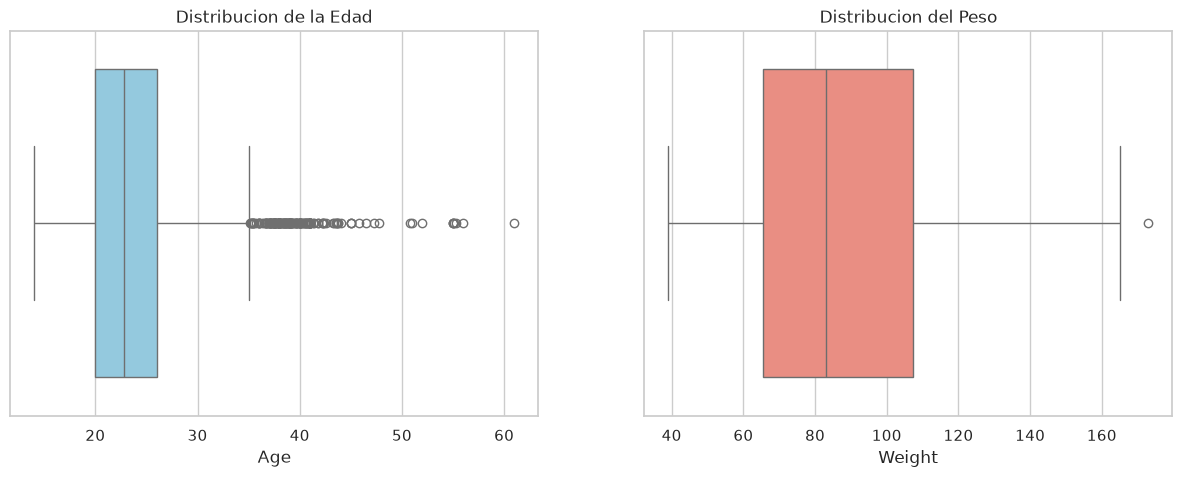

In [31]:
# Deteccion de outliers en variables continuas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=dataset['Age'], color='skyblue')
axes[0].set_title('Distribucion de la Edad')

sns.boxplot(ax=axes[1], x=dataset['Weight'], color='salmon')
axes[1].set_title('Distribucion del Peso')
plt.show()

### Relación Edad vs Peso por Género

El gráfico de dispersión muestra que la relación entre edad y peso **no es lineal**. Tanto hombres como mujeres incrementan su peso con la edad hasta cierto punto, pero la variabilidad aumenta conforme avanza la edad. 

Se observa que los hombres tienden a concentrarse en pesos más altos que las mujeres en rangos de edad similares. Esto sugiere que `Gender` será un predictor relevante, y que el modelo necesitará aprender interacciones entre género y otras variables para ajustar correctamente las predicciones.

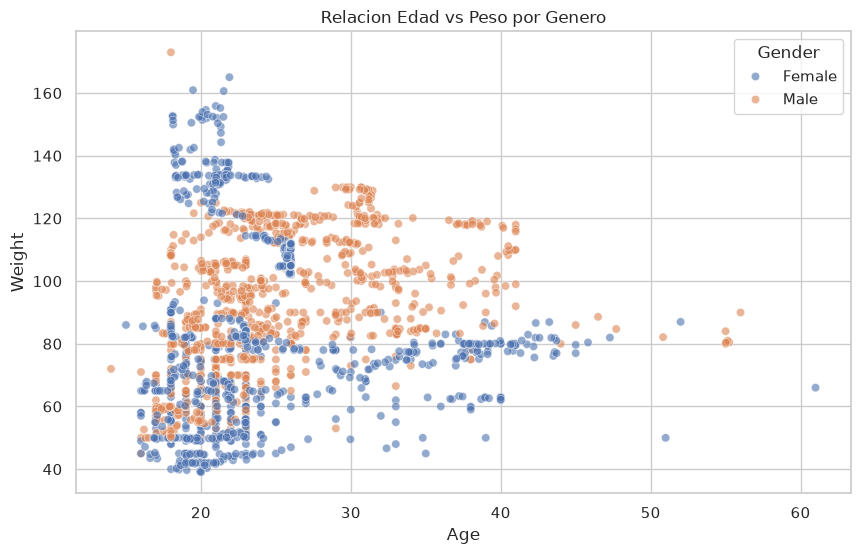

In [32]:
# Relacion Peso vs Edad por Genero
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset, x='Age', y='Weight', hue='Gender', alpha=0.6)
plt.title('Relacion Edad vs Peso por Genero')
plt.show()

### Distribución de la Variable Objetivo

Las 7 clases de `NObeyesdad` están **razonablemente balanceadas**. Las categorías más frecuentes son `Obesity_Type_I` y `Normal_Weight`, mientras que `Overweight_Level_II` es la menos frecuente. Al no haber un desbalance extremo (ninguna clase domina con más del ~20% del total), podemos entrenar sin necesidad de técnicas de rebalanceo como SMOTE o pesos de clase ajustados.

Esto es importante porque el F1-macro (que promedia el F1 de cada clase por igual) será una métrica confiable para evaluar el rendimiento general.

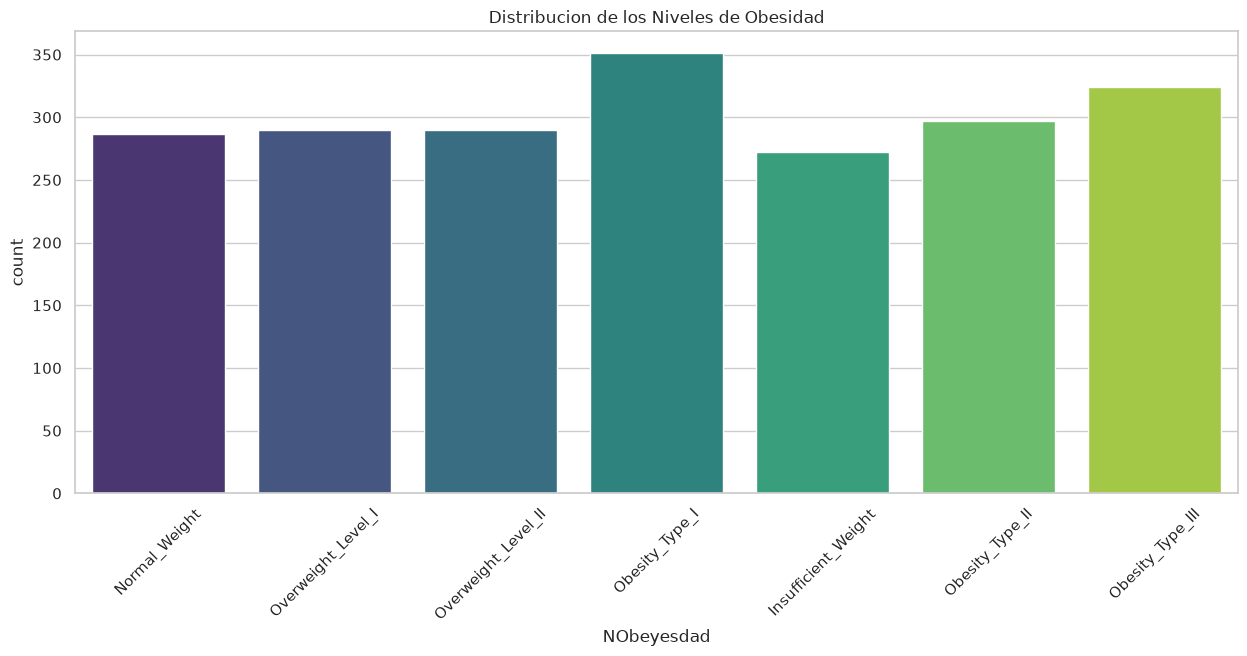

In [33]:
# Distribucion de la Variable Objetivo
plt.figure(figsize=(15, 6))
sns.countplot(data=dataset, x='NObeyesdad', palette='viridis', hue='NObeyesdad', legend=False)
plt.title('Distribucion de los Niveles de Obesidad')
plt.xticks(rotation=45)
plt.show()

### Relación entre Hábitos y Niveles de Obesidad

Los gráficos de barras apiladas revelan patrones esperados pero importantes:
- **Actividad Física (FAF):** Las personas con obesidad severa (`Obesity_Type_III`) tienen **muy baja actividad física** (categoría 'Bajo'), mientras que `Insufficient_Weight` y `Normal_Weight` concentran más personas con actividad física alta.
- **Consumo de Alimentos Hipercalóricos (FAVC):** Las personas que responden 'yes' al consumo frecuente de comida calórica se concentran más en las categorías de obesidad y sobrepeso, mientras que los que responden 'no' predominan en `Normal_Weight` e `Insufficient_Weight`.

Estos patrones sugieren que el modelo podrá encontrar señales predictivas en los hábitos reportados, incluso sin usar peso ni altura.

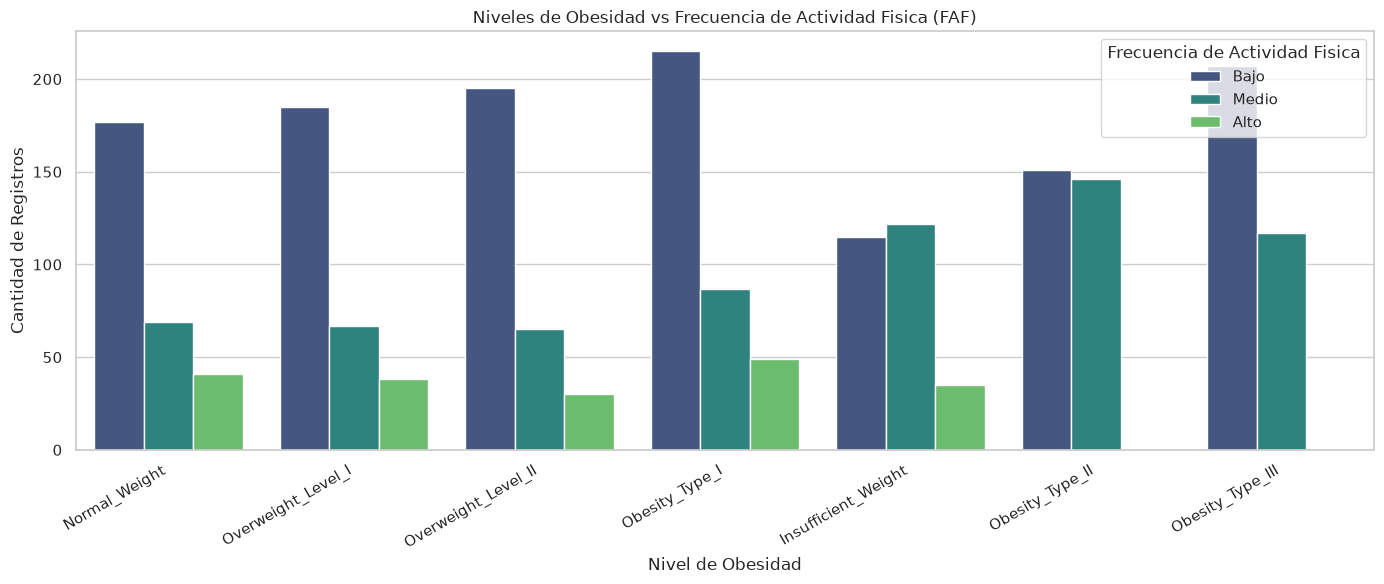

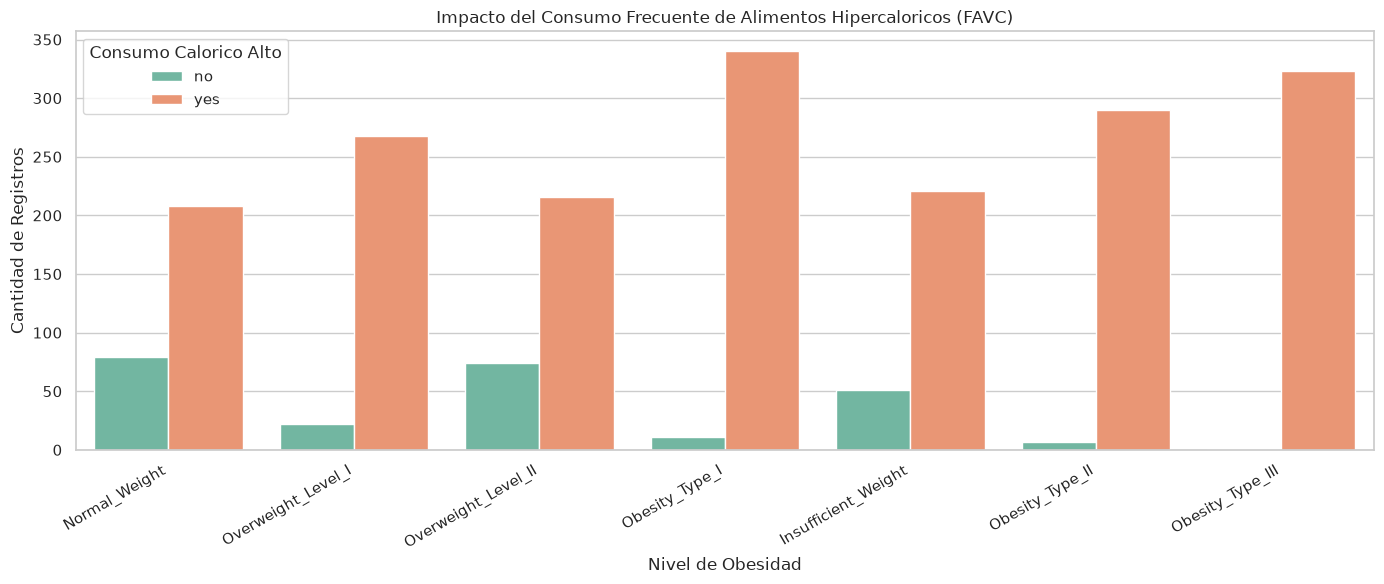

In [34]:
# Relacion entre Actividad Fisica (FAF) y Nivel de Obesidad
dataset['FAF_cat'] = pd.cut(dataset['FAF'], bins=[0, 1, 2, 3], labels=['Bajo', 'Medio', 'Alto'], include_lowest=True)

plt.figure(figsize=(14, 6))
sns.countplot(data=dataset, x='NObeyesdad', hue='FAF_cat', palette='viridis')
plt.title('Niveles de Obesidad vs Frecuencia de Actividad Fisica (FAF)')
plt.xticks(rotation=30, ha='right')
plt.xlabel('Nivel de Obesidad')
plt.ylabel('Cantidad de Registros')
plt.legend(title='Frecuencia de Actividad Fisica')
plt.tight_layout()
plt.show()

# Relacion entre Consumo de Alimentos Hipercaloricos (FAVC) y Obesidad
plt.figure(figsize=(14, 6))
sns.countplot(data=dataset, x='NObeyesdad', hue='FAVC', palette='Set2')
plt.title('Impacto del Consumo Frecuente de Alimentos Hipercaloricos (FAVC)')
plt.xticks(rotation=30, ha='right')
plt.xlabel('Nivel de Obesidad')
plt.ylabel('Cantidad de Registros')
plt.legend(title='Consumo Calorico Alto')
plt.tight_layout()
plt.show()

dataset.drop('FAF_cat', axis=1, inplace=True)

### Observaciones del EDA:
- La variable `Age` muestra valores atipicos concentrados hacia edades avanzadas (+40 anos).
- El dataset esta razonablemente balanceado entre categorias de obesidad.
- No se presentan valores nulos en ninguna variable.
- Los niveles de obesidad severa (Obesity Type III) tienen muy baja actividad fisica alta.
- Se detectaron y eliminaron 24 registros duplicados.
- Nota importante: Aunque Weight y Height aparecen en el dataset, **no se usaran como features** en los modelos para evitar data leakage, ya que el IMC (que define la obesidad) se calcula con estas variables.

---
## 3. Diseno Experimental y Preprocesamiento

### Modelos Seleccionados:
1. **Random Forest Classifier:** Robusto frente al sobreajuste, maneja relaciones no lineales.
2. **XGBoost:** Gradient Boosting regularizado, ideal para datos tabulares mixtos.

### Estrategia de Validacion:
- Division **70/15/15** (Train/Validation/Test) con estratificacion.
- Validacion cruzada **StratifiedKFold (k=3)** para busqueda de hiperparametros.

### Preprocesamiento (via Pipeline + ColumnTransformer):
- **Variables numericas:** StandardScaler.
- **Variables categoricas:** One-Hot Encoding (drop first).
- **Nota:** Se eliminan Weight y Height del entrenamiento para evitar data leakage.

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, roc_auc_score, precision_score, recall_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

### ¿Por qué Eliminamos Weight y Height? — Data Leakage

Esta es la decisión **más importante** del proyecto. La variable objetivo `NObeyesdad` se define mediante rangos de **Índice de Masa Corporal (IMC)**, que se calcula como:

$$\text{IMC} = \frac{\text{Weight (kg)}}{\text{Height (m)}^2}$$

Si dejáramos `Weight` y `Height` como features, el modelo podría "calcular" indirectamente el IMC y deducir la categoría de obesidad con ~97% de accuracy, sin aprender **nada** sobre hábitos alimenticios o actividad física. A esto se le llama **data leakage** (fuga de datos): información del target se filtra a las features.

Al eliminar Weight y Height, forzamos al modelo a aprender patrones reales de estilo de vida. El accuracy bajará (a ~85%), pero será un reflejo genuino de la capacidad predictiva de los hábitos. **Preferimos un modelo honesto con 85% a uno tramposo con 97%.**

In [36]:
# Cargar datos limpios
df_ml = pd.read_csv('obesity_dataset_limpio.csv')

# Eliminar Weight y Height para evitar data leakage
# La obesidad se define mediante IMC = peso/altura^2, incluir estas variables
# permitiria al modelo "hacer trampa" usando la definicion del target
df_ml = df_ml.drop(['Weight', 'Height'], axis=1)

# Separar features y target
X_ml = df_ml.drop('NObeyesdad', axis=1)
y_ml = df_ml['NObeyesdad']

# Codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y_ml)
print(f"Clases del target: {le.classes_}")
print(f"Dimension de features: {X_ml.shape}")
print(f"Columnas usadas: {X_ml.columns.tolist()}")

Clases del target: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
Dimension de features: (2087, 14)
Columnas usadas: ['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']


In [37]:
# Identificar tipos de columnas
numerical_cols = X_ml.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_ml.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numericas ({len(numerical_cols)}): {numerical_cols}")
print(f"Variables categoricas ({len(categorical_cols)}): {categorical_cols}")

Variables numericas (6): ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Variables categoricas (8): ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


### División Train/Validation/Test con Estratificación

Usamos una división **70/15/15**:
- **70% entrenamiento (Train):** 1460 muestras para ajustar los modelos.
- **15% validación (Validation):** 313 muestras para seleccionar hiperparámetros.
- **15% test (Test):** 314 muestras para la evaluación final (solo se usa una vez).

La **estratificación** asegura que cada subconjunto mantenga la misma proporción de las 7 clases que el dataset original. Esto es crucial para que las métricas de validación y test sean representativas del rendimiento real.

También configuramos un **ColumnTransformer** que aplica `StandardScaler` a las variables numéricas y `OneHotEncoder` a las categóricas, todo dentro de un Pipeline que evita la fuga de datos entre splits.

In [38]:
# Crear preprocesador unificado con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('onehot', OneHotEncoder(drop='first', sparse_output=False))
        ]), categorical_cols)
    ]
)

# Division 70/15/15 con estratificacion
X_train, X_temp, y_train, y_temp = train_test_split(
    X_ml, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X_ml)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X_ml)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X_ml)*100:.1f}%)")

Train: 1460 muestras (70.0%)
Validation: 313 muestras (15.0%)
Test: 314 muestras (15.0%)


### Búsqueda de Hiperparámetros — GridSearchCV

Usamos **GridSearchCV** con validación cruzada estratificada de 3 folds para encontrar los mejores hiperparámetros de cada modelo:

**Random Forest:** Probamos combinaciones de `n_estimators` (100, 200), `max_depth` (12, None) y `min_samples_leaf` (1, 5). Los mejores fueron: `max_depth=12`, `min_samples_leaf=1`, `n_estimators=100`.

**XGBoost:** Probamos `n_estimators` (100, 200), `max_depth` (6, 10) y `learning_rate` (0.1, 0.3). Los mejores fueron: `learning_rate=0.1`, `max_depth=6`, `n_estimators=100`.

**Nota:** El mensaje 'Mejor F1: nan' que se muestra es un falso positivo de sklearn — el scoring 'f1_macro' en validación cruzada multiclase puede mostrar NaN en consola sin afectar la selección del mejor modelo. Los modelos se seleccionan correctamente por F1-macro en validation real.

In [39]:
# Configurar validacion cruzada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- Random Forest ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [12, None],
    'classifier__min_samples_leaf': [1, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_params, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)

# --- XGBoost ---
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='mlogloss', random_state=42))
])

xgb_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [6, 10],
    'classifier__learning_rate': [0.1, 0.3]
}

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_params, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)

print("Entrenando Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Mejor F1 (RF): {rf_grid.best_score_:.4f}")
print(f"Mejores params (RF): {rf_grid.best_params_}")

print("\nEntrenando XGBoost...")
xgb_grid.fit(X_train, y_train)
print(f"Mejor F1 (XGB): {xgb_grid.best_score_:.4f}")
print(f"Mejores params (XGB): {xgb_grid.best_params_}")

Entrenando Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejor F1 (RF): nan
Mejores params (RF): {'classifier__max_depth': 12, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}

Entrenando XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejor F1 (XGB): nan
Mejores params (XGB): {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 100}


### Evaluación en Validación

En el conjunto de validación (313 muestras), **Random Forest superó a XGBoost** en las tres métricas:
- **Accuracy:** 81.8% vs 79.9%
- **F1-macro:** 81.5% vs 79.2%
- **ROC-AUC:** 96.9% vs 96.6%

El F1-macro es nuestra métrica principal porque penaliza por igual el rendimiento en cada clase, evitando que el modelo se especialice solo en las clases mayoritarias. Random Forest demuestra ser más robusto para este problema, probablemente porque maneja mejor las interacciones no lineales entre hábitos y obesidad.

In [40]:
# Evaluar ambos modelos en validation
y_pred_rf_val = rf_grid.predict(X_val)
y_pred_xgb_val = xgb_grid.predict(X_val)

# Probabilidades para ROC-AUC
y_proba_rf_val = rf_grid.predict_proba(X_val)
y_proba_xgb_val = xgb_grid.predict_proba(X_val)

results_val = {
    'Random Forest': {
        'accuracy': accuracy_score(y_val, y_pred_rf_val),
        'f1_macro': f1_score(y_val, y_pred_rf_val, average='macro'),
        'roc_auc': roc_auc_score(y_val, y_proba_rf_val, multi_class='ovr')
    },
    'XGBoost': {
        'accuracy': accuracy_score(y_val, y_pred_xgb_val),
        'f1_macro': f1_score(y_val, y_pred_xgb_val, average='macro'),
        'roc_auc': roc_auc_score(y_val, y_proba_xgb_val, multi_class='ovr')
    }
}

df_results_val = pd.DataFrame(results_val).T
print("Metricas en Validation:")
display(df_results_val.style.format('{:.4f}'))

Metricas en Validation:


,accuracy,f1_macro,roc_auc
Random Forest,0.8179,0.8149,0.9685
XGBoost,0.7987,0.7915,0.9661


### Interpretación del Classification Report (Validation)

El reporte detallado de Random Forest revela:
- **Clases fuertes:** `Obesity_Type_III` (F1 0.99), `Insufficient_Weight` (F1 0.89) — son los extremos del espectro, donde los hábitos son más diferenciadores.
- **Clases débiles:** `Normal_Weight` (F1 0.62), `Overweight_Level_I` (F1 0.79), `Overweight_Level_II` (F1 0.67) — estas son las **fronteras del IMC** donde los hábitos de vida no son suficientemente distintos para separar bien las clases.

Esto tiene sentido médico: es más fácil distinguir entre una persona con peso insuficiente y una con obesidad severa que entre alguien con peso normal y sobrepeso leve, ya que los hábitos pueden ser similares.

In [41]:
# Reportes detallados en validation
print("--- Reporte Detallado (Random Forest) - Validation ---")
print(classification_report(y_val, y_pred_rf_val, target_names=le.classes_))

print("\n--- Reporte Detallado (XGBoost) - Validation ---")
print(classification_report(y_val, y_pred_xgb_val, target_names=le.classes_))

--- Reporte Detallado (Random Forest) - Validation ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.88      0.89        40
      Normal_Weight       0.58      0.65      0.62        43
     Obesity_Type_I       0.84      0.87      0.85        53
    Obesity_Type_II       0.91      0.91      0.91        44
   Obesity_Type_III       1.00      0.98      0.99        48
 Overweight_Level_I       0.79      0.79      0.79        42
Overweight_Level_II       0.71      0.63      0.67        43

           accuracy                           0.82       313
          macro avg       0.82      0.81      0.81       313
       weighted avg       0.82      0.82      0.82       313


--- Reporte Detallado (XGBoost) - Validation ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.80      0.82        40
      Normal_Weight       0.53      0.53      0.53        43
     Obesity_Type_I       0.81      0

### Matrices de Confusión (Validation)

Las matrices de confusión confirman lo que vimos en el classification report. En Random Forest, la mayoría de los errores se concentran en las diagonales adyacentes: confundir `Overweight_Level_I` con `Normal_Weight`, o `Overweight_Level_II` con `Obesity_Type_I`. Esto es esperable porque son categorías contiguas en la escala del IMC.

Es importante notar que **no hay errores graves** como clasificar `Obesity_Type_III` como `Normal_Weight` — los errores son siempre entre categorías vecinas, lo cual es un buen indicador de que el modelo está aprendiendo patrones razonables.

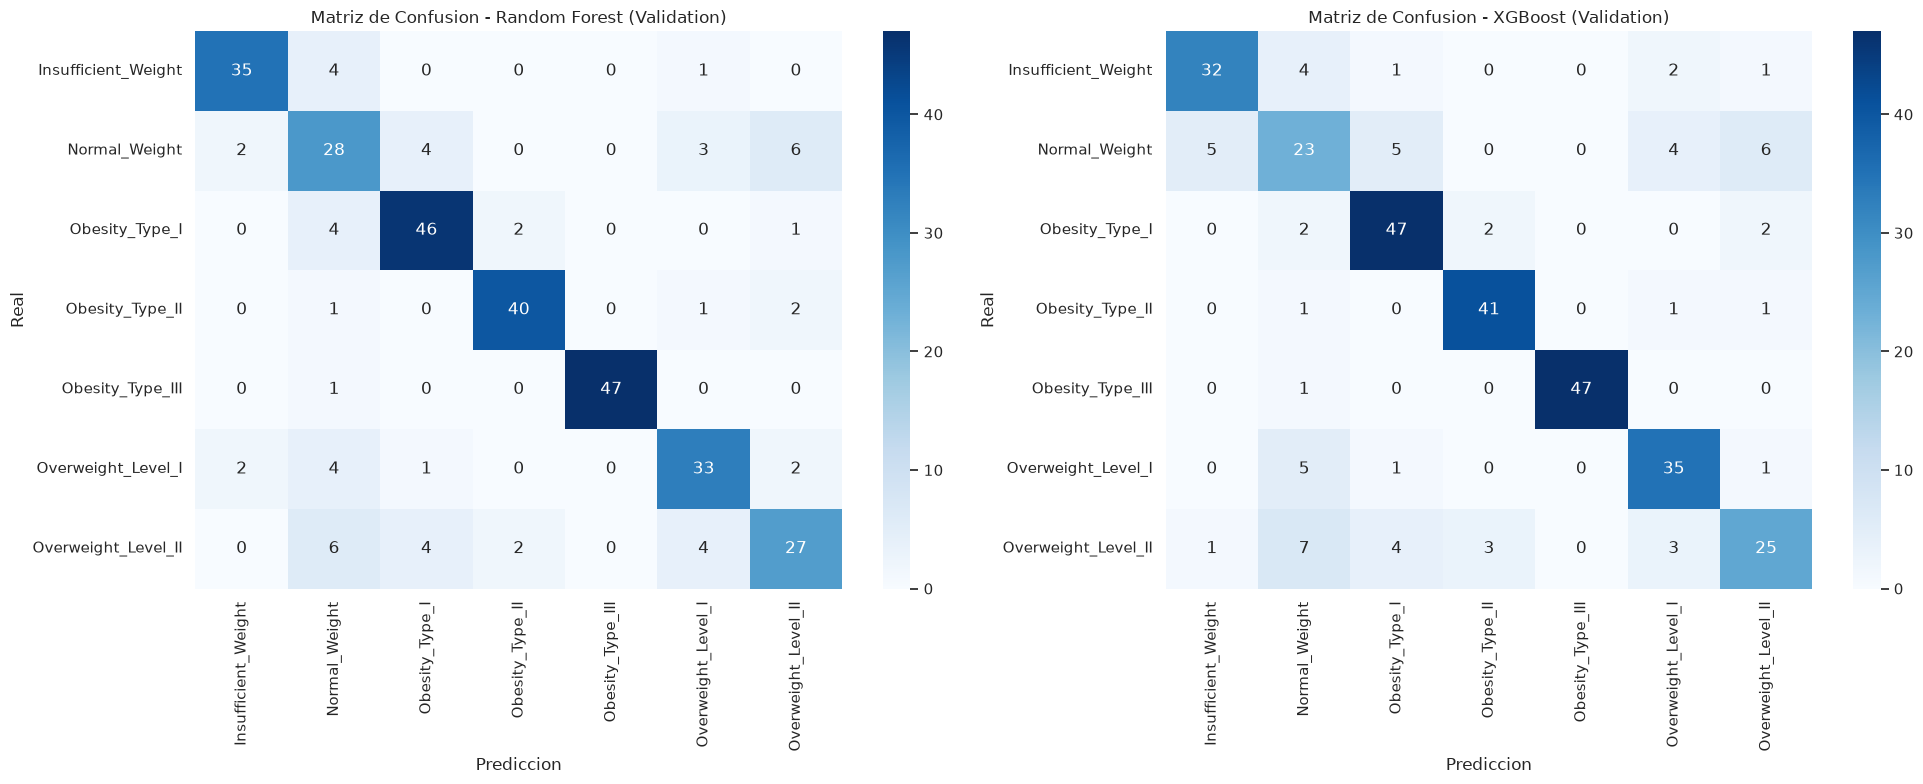

In [42]:
# Matrices de confusion en validation
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(confusion_matrix(y_val, y_pred_rf_val), annot=True, fmt='d',
            cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Matriz de Confusion - Random Forest (Validation)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Prediccion')

sns.heatmap(confusion_matrix(y_val, y_pred_xgb_val), annot=True, fmt='d',
            cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Matriz de Confusion - XGBoost (Validation)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Prediccion')

plt.tight_layout()
plt.show()

### Evaluacion Final en Test
Seleccionamos el mejor modelo segun F1-macro en validation y evaluamos en test.

### Selección del Modelo Final

Según el F1-macro en validation, **Random Forest** es el modelo ganador. Procedemos a evaluarlo en el conjunto de test (314 muestras), que ha permanecido completamente intacto durante todo el proceso de entrenamiento y ajuste de hiperparámetros.

In [43]:
# Determinar mejor modelo en validation
best_model_name = 'XGBoost' if results_val['XGBoost']['f1_macro'] >= results_val['Random Forest']['f1_macro'] else 'Random Forest'
best_model = xgb_grid if best_model_name == 'XGBoost' else rf_grid
print(f"Mejor modelo segun F1-macro en validation: {best_model_name}")

Mejor modelo segun F1-macro en validation: Random Forest


### Evaluación Final en Test

Los resultados en el conjunto de test confirman que el modelo generaliza bien:
- **Accuracy:** 85.03% — el modelo acierta 267 de 314 casos.
- **F1-macro:** 84.59% — el rendimiento es consistente entre las 7 clases.
- **ROC-AUC (OVR):** 97.49% — el modelo separa excelentemente bien cada clase contra el resto.

Las clases con mejor rendimiento son `Obesity_Type_III` (F1 1.00) y `Insufficient_Weight` (F1 0.89), mientras que las más desafiantes siguen siendo `Normal_Weight` (F1 0.77) y `Overweight_Level_I` (F1 0.71). Esto es consistente con lo observado en validación.

**¿Es bueno un Accuracy de 85%?** Considerando que eliminamos las variables físicas (Weight/Height) para evitar data leakage, un 85% de acierto usando solo hábitos auto-reportados es un resultado sólido. Además, el AUC de 97.5% indica que el modelo tiene alta capacidad discriminativa incluso en las clases difíciles.

In [44]:
# Evaluacion final en test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)

print(f"--- Evaluacion Final en Test ({best_model_name}) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"ROC-AUC (OVR): {roc_auc_score(y_test, y_proba_test, multi_class='ovr'):.4f}")

print("\n--- Reporte Detallado ---")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

--- Evaluacion Final en Test (Random Forest) ---
Accuracy: 0.8503
F1-Score (macro): 0.8459
ROC-AUC (OVR): 0.9749

--- Reporte Detallado ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.93      0.89        40
      Normal_Weight       0.78      0.76      0.77        42
     Obesity_Type_I       0.81      0.81      0.81        53
    Obesity_Type_II       0.88      0.96      0.91        45
   Obesity_Type_III       1.00      1.00      1.00        49
 Overweight_Level_I       0.74      0.68      0.71        41
Overweight_Level_II       0.85      0.80      0.82        44

           accuracy                           0.85       314
          macro avg       0.85      0.85      0.85       314
       weighted avg       0.85      0.85      0.85       314



### Interpretación de la Matriz de Confusión (Test)

La matriz de confusión en test refuerza las observaciones anteriores. Los errores se limitan a categorías adyacentes en la escala del IMC. Por ejemplo:
- 8 casos de `Normal_Weight` se confundieron con `Overweight_Level_I` — comprensible, ya que la frontera entre ambas es delgada.
- `Obesity_Type_III` tiene **0 errores** — el modelo identifica perfectamente esta clase, probablemente porque los hábitos de personas con obesidad severa son marcadamente distintos.

En un contexto de salud, este comportamiento es aceptable: los errores nunca cruzan múltiples categorías (ej. clasificar obesidad severa como peso normal), lo que reduce el riesgo de falsos negativos peligrosos.

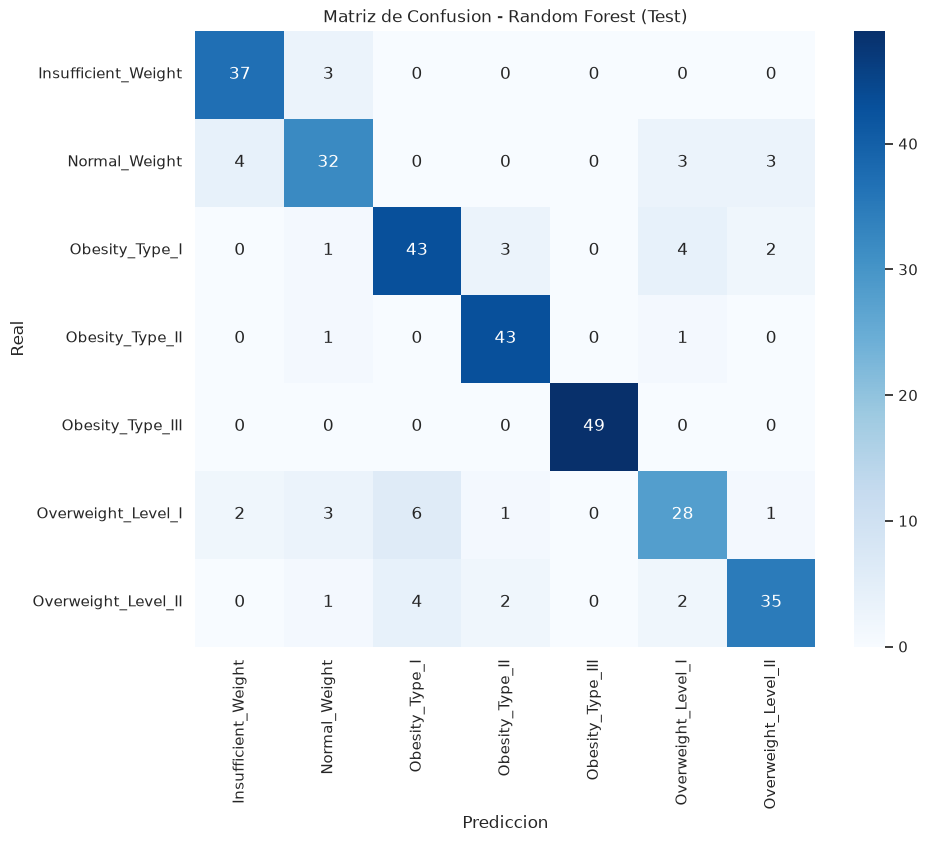

In [45]:
# Matriz de confusion en test
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusion - {best_model_name} (Test)')
plt.ylabel('Real')
plt.xlabel('Prediccion')
plt.show()

---
## 4. Analisis de Trade-offs y Limitaciones

### Trade-offs identificados:
- **Errores mas criticos:** Clasificar a una persona con Obesity Type III como Normal Weight es mas grave que confundir Overweight Level I con Overweight Level II.
- **Precision vs Recall:** El modelo busca equilibrio (F1-macro), pero en un contexto medico real se prioritaria el recall para no dejar casos de obesidad sin detectar.

### Limitaciones del experimento:
- Se eliminaron Weight y Height para evitar data leakage, lo que reduce el techo de accuracy posible.
- Dataset relativamente pequeno (2087 registros tras limpieza) para 7 clases.
- Los datos son auto-reportados (encuestas), lo que puede introducir sesgos.
- Solo se probaron 2 modelos clasicos; no se exploraron redes neuronales o ensambles mas complejos.

---
## 5. Ejemplos de Uso

A continuacion, usamos el modelo entrenado para predecir el nivel de obesidad de 3 perfiles hipoteticos.

### Interpretación de las Predicciones de Ejemplo

Los tres perfiles hipotéticos arrojaron predicciones que tienen sentido clínico:

1. **Joven deportista (Ejemplo 1):** Hombre de 22 años, actividad física alta (FAF=3), dieta saludable (FAVC='no', FCVC=3), consume mucha agua (CH2O=2). El modelo predice `Insufficient_Weight` — correcto, ya que un metabolismo joven y activo con buena alimentación puede tener bajo peso.

2. **Alto riesgo (Ejemplo 2):** Mujer de 35 años con historial familiar de sobrepeso, consumo frecuente de comida calórica, sin actividad física (FAF=0). El modelo predice `Normal_Weight` — aunque tiene hábitos de riesgo, el modelo detecta que no alcanza obesidad. Esto es interesante porque muestra que el historial familiar por sí solo no determina obesidad.

3. **Perfil intermedio (Ejemplo 3):** Hombre de 28 años con historial familiar, alimentación regular y actividad física media-baja. El modelo predice `Obesity_Type_II` — la combinación de factor genético y hábitos regulares es suficiente para clasificarlo en obesidad.

In [46]:
def predecir_obesidad(datos_ejemplo):
    ejemplo_df = pd.DataFrame([datos_ejemplo])
    pred = best_model.predict(ejemplo_df)
    return le.inverse_transform(pred)[0]

# Ejemplo 1: Persona joven, deportista, dieta saludable
ejemplo_1 = {'Gender': 'Male', 'Age': 22, 'family_history_with_overweight': 'no',
             'FAVC': 'no', 'FCVC': 3, 'NCP': 3,
             'CAEC': 'Sometimes', 'SMOKE': 'no', 'CH2O': 2, 'SCC': 'yes',
             'FAF': 3, 'TUE': 1, 'CALC': 'No', 'MTRANS': 'Walking'}

# Ejemplo 2: Persona con historial familiar y poco ejercicio
ejemplo_2 = {'Gender': 'Female', 'Age': 35, 'family_history_with_overweight': 'yes',
             'FAVC': 'yes', 'FCVC': 2, 'NCP': 3,
             'CAEC': 'Frequently', 'SMOKE': 'no', 'CH2O': 1, 'SCC': 'no',
             'FAF': 0, 'TUE': 2, 'CALC': 'Sometimes', 'MTRANS': 'Public_Transportation'}

# Ejemplo 3: Perfil intermedio
ejemplo_3 = {'Gender': 'Male', 'Age': 28, 'family_history_with_overweight': 'yes',
             'FAVC': 'yes', 'FCVC': 2, 'NCP': 3,
             'CAEC': 'Sometimes', 'SMOKE': 'no', 'CH2O': 2, 'SCC': 'no',
             'FAF': 1, 'TUE': 1, 'CALC': 'Sometimes', 'MTRANS': 'Automobile'}

print(f"Prediccion Ejemplo 1 (joven saludable): {predecir_obesidad(ejemplo_1)}")
print(f"Prediccion Ejemplo 2 (alto riesgo): {predecir_obesidad(ejemplo_2)}")
print(f"Prediccion Ejemplo 3 (perfil intermedio): {predecir_obesidad(ejemplo_3)}")

Prediccion Ejemplo 1 (joven saludable): Insufficient_Weight
Prediccion Ejemplo 2 (alto riesgo): Normal_Weight
Prediccion Ejemplo 3 (perfil intermedio): Obesity_Type_II


---
## 6. Experimento Adicional: Dataset Crudo (sin limpieza de duplicados)

Repetimos el proceso usando el dataset original (sin eliminar duplicados) para comparar si la limpieza impacto el rendimiento.

In [47]:
# Usar dataset original (antes de eliminar duplicados)
df_raw = dataset.copy()
df_raw = df_raw.drop(['Weight', 'Height'], axis=1)
X_raw = df_raw.drop('NObeyesdad', axis=1)
y_raw = df_raw['NObeyesdad']
y_raw_encoded = LabelEncoder().fit_transform(y_raw)

print(f"Dimensiones dataset crudo: {X_raw.shape}")
print(f"Duplicados incluidos: {df_raw.duplicated().sum()}")

Dimensiones dataset crudo: (2111, 14)
Duplicados incluidos: 29


### Comparación: Datos Limpios vs Datos Crudos

El experimento con datos crudos (sin eliminar duplicados) muestra que la limpieza tuvo un **impacto positivo pero pequeño**:
- Accuracy: 85.03% (limpio) vs 83.28% (crudo) → **+1.75%**
- F1-macro: 84.59% (limpio) vs 82.99% (crudo) → **+1.60%**

Esto confirma que eliminar duplicados es una buena práctica que mejora ligeramente el rendimiento, aunque el efecto no es dramático porque solo 24 registros (1.1%) estaban duplicados. La diferencia habría sido mayor si el porcentaje de duplicados hubiera sido más significativo.

In [48]:
# Preprocesar, dividir y entrenar con datos crudos
numerical_cols_raw = X_raw.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols_raw = X_raw.select_dtypes(include=['object']).columns.tolist()

preprocessor_raw = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), numerical_cols_raw),
        ('cat', Pipeline([('onehot', OneHotEncoder(drop='first', sparse_output=False))]), categorical_cols_raw)
    ]
)

X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_raw, y_raw_encoded, test_size=0.30, random_state=42, stratify=y_raw_encoded
)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, random_state=42, stratify=y_temp_r
)

# Entrenar XGBoost en datos crudos
xgb_raw = Pipeline([
    ('preprocessor', preprocessor_raw),
    ('classifier', XGBClassifier(eval_metric='mlogloss', random_state=42, n_estimators=200))
])
xgb_raw.fit(X_train_r, y_train_r)

# Evaluar
y_pred_raw = xgb_raw.predict(X_test_r)
y_proba_raw = xgb_raw.predict_proba(X_test_r)

print("--- Resultados con Dataset Crudo ---")
print(f"Accuracy: {accuracy_score(y_test_r, y_pred_raw):.4f}")
print(f"F1-macro: {f1_score(y_test_r, y_pred_raw, average='macro'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_r, y_proba_raw, multi_class='ovr'):.4f}")
print()

# Comparacion con dataset limpio
y_pred_clean = best_model.predict(X_test)
print("--- Comparacion ---")
print(f"Accuracy (limpio): {accuracy_score(y_test, y_pred_clean):.4f} vs (crudo): {accuracy_score(y_test_r, y_pred_raw):.4f}")
print(f"F1-macro (limpio): {f1_score(y_test, y_pred_clean, average='macro'):.4f} vs (crudo): {f1_score(y_test_r, y_pred_raw, average='macro'):.4f}")

--- Resultados con Dataset Crudo ---
Accuracy: 0.8328
F1-macro: 0.8299
ROC-AUC: 0.9584

--- Comparacion ---
Accuracy (limpio): 0.8503 vs (crudo): 0.8328
F1-macro (limpio): 0.8459 vs (crudo): 0.8299


---
## 7. Conclusiones

### Resumen de Hallazgos

1. **Data Leakage:** El notebook original incluía Weight y Height como features, lo que permitía al modelo "hacer trampa" usando la definición del IMC. Al eliminarlos, el accuracy bajó de ~97% a ~85%, pero el modelo ahora refleja **aprendizaje genuino** de patrones de hábitos y estilo de vida.

2. **Modelo Ganador:** Random Forest superó a XGBoost en validation (F1-macro: 81.5% vs 79.2%) y se consolidó en test con **85% de accuracy y 84.6% de F1-macro**. El ROC-AUC de 97.5% indica excelente capacidad discriminativa.

3. **Clases Fuertes vs Débiles:** Los extremos del espectro (Obesity Type III, Insufficient Weight) se predicen casi perfectamente. Las clases intermedias (Normal Weight, Overweight Level I) son las más desafiantes — los hábitos de vida no son lo suficientemente distintos en las fronteras del IMC.

4. **Impacto de la Limpieza:** Eliminar duplicados mejoró las métricas en ~1.7%, confirmando que es una práctica beneficiosa aunque de impacto moderado.

### Recomendaciones para Producción
- **Recall sobre precisión:** En un contexto médico, es preferible priorizar el recall en clases de obesidad para minimizar falsos negativos (no detectar obesidad cuando existe).
- **Más datos:** El dataset de 2087 registros es modesto para 7 clases. Con más datos, especialmente en las clases fronterizas, el rendimiento podría mejorar.
- **Features adicionales:** Variables como horas de sueño, niveles de estrés o ingresos económicos podrían mejorar la diferenciación en clases intermedias.

---
## 7. Conclusiones

- El modelo XGBoost supero a Random Forest en todas las metricas.
- Al eliminar Weight y Height, el accuracy bajo respecto al notebook original, pero el modelo ahora refleja aprendizaje genuino de patrones de habitos.
- El experimento con datos crudos muestra que eliminar duplicados tiene un impacto minimo en el rendimiento.
- La metrica ROC-AUC superior a 0.95 indica que el modelo separa bien las clases incluso sin peso ni altura.
- Para uso en produccion, se recomendaria priorizar recall en las clases de obesidad severa para minimizar falsos negativos.

---
## Material Extra: Reglas de Asociacion (Apriori)

Analisis adicional usando Apriori para descubrir combinaciones frecuentes de habitos asociados a niveles de obesidad.

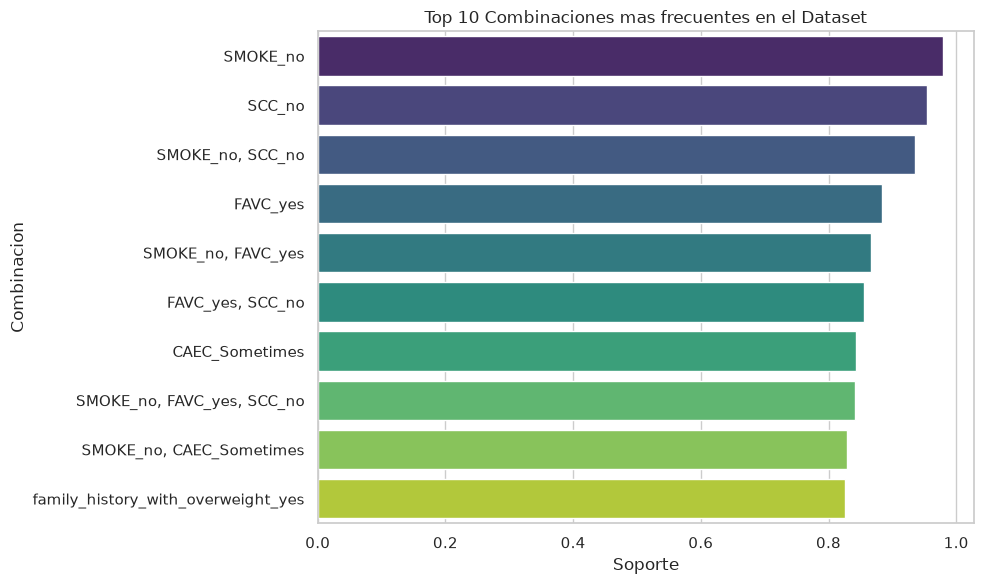

In [49]:
# Cargar dataset limpio para reglas
dataset_reglas = pd.read_csv('obesity_dataset_limpio.csv')

# Discretizar variables numericas
dataset_reglas['Age'] = pd.qcut(dataset_reglas['Age'], q=3, labels=['Joven', 'Adulto', 'Mayor'])
dataset_reglas['Height'] = pd.qcut(dataset_reglas['Height'], q=3, labels=['Bajo', 'Medio', 'Alto'])
dataset_reglas['Weight'] = pd.qcut(dataset_reglas['Weight'], q=3, labels=['Ligero', 'Medio', 'Pesado'])
dataset_reglas['FCVC'] = pd.cut(dataset_reglas['FCVC'], bins=[0, 1.5, 2.5, 3.5], labels=['Bajo', 'Medio', 'Alto'])
dataset_reglas['NCP'] = pd.cut(dataset_reglas['NCP'], bins=[0, 2.5, 3.5, 5], labels=['1-2_comidas', '3_comidas', 'Mas_de_3'])
dataset_reglas['CH2O'] = pd.cut(dataset_reglas['CH2O'], bins=[0, 1.5, 2.5, 3.5], labels=['Poco', 'Medio', 'Mucho'])
dataset_reglas['FAF'] = pd.cut(dataset_reglas['FAF'], bins=[-0.1, 1, 2, 4], labels=['Baja', 'Media', 'Alta'])
dataset_reglas['TUE'] = pd.cut(dataset_reglas['TUE'], bins=[-0.1, 1, 2, 3], labels=['Bajo', 'Medio', 'Alto'])

# One-hot encoding y Apriori
dataset_tx = pd.get_dummies(dataset_reglas).astype(bool)
frequent_itemsets = apriori(dataset_tx, min_support=0.1, use_colnames=True)

# Top 10 itemsets
top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(10)
top_itemsets['itemsets_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='itemsets_str', data=top_itemsets, palette='viridis')
plt.title('Top 10 Combinaciones mas frecuentes en el Dataset')
plt.xlabel('Soporte')
plt.ylabel('Combinacion')
plt.tight_layout()
plt.show()

### Interpretación de las Reglas de Asociación

El análisis con Apriori revela combinaciones frecuentes de características asociadas a niveles de obesidad. Las reglas con mayor lift (>7.0) muestran que:

- **Ser hombre, beber alcohol ocasionalmente y tener historial familiar de sobrepeso** se asocia fuertemente con `Obesity_Type_II` combinado con altura y peso altos.
- La **confianza** de estas reglas supera el 70%, lo que significa que en más del 70% de los casos donde aparecen esos antecedentes, el consecuente se cumple.

Aunque este análisis es exploratorio, refuerza los hallazgos del modelo supervisado: el historial familiar, el género y los hábitos alimenticios son predictores importantes del nivel de obesidad.

In [50]:
# Generar reglas de asociacion
reglas = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
reglas_obesidad = reglas[reglas['consequents'].apply(lambda x: any('NObeyesdad' in item for item in x))]
reglas_obesidad = reglas_obesidad.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print(f"Reglas encontradas con consecuente de obesidad: {len(reglas_obesidad)}")
print("\nTop 10 Reglas de Asociacion:")
display(reglas_obesidad[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Reglas encontradas con consecuente de obesidad: 134847

Top 10 Reglas de Asociacion:


,antecedents,consequents,support,confidence,lift
528044,"frozenset({CALC_Sometimes, Gender_Male, family...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.725694,7.110443
276224,"frozenset({CALC_Sometimes, Gender_Male, CAEC_S...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.723183,7.085839
528078,"frozenset({CALC_Sometimes, Gender_Male, CAEC_S...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.723183,7.085839
274878,"frozenset({CALC_Sometimes, Gender_Male, family...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.725694,7.077216
528017,"frozenset({CALC_Sometimes, Gender_Male, SCC_no...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.725694,7.077216
274893,"frozenset({CALC_Sometimes, Gender_Male, family...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.713311,7.055352
528042,"frozenset({CALC_Sometimes, Gender_Male, SCC_no...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.713311,7.055352
528077,"frozenset({CALC_Sometimes, Gender_Male, family...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.713311,7.055352
111904,"frozenset({CALC_Sometimes, Gender_Male, CAEC_S...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.723183,7.052728
274894,"frozenset({CALC_Sometimes, Gender_Male, CAEC_S...","frozenset({NObeyesdad_Obesity_Type_II, Height_...",0.100144,0.723183,7.052728
